
# SolarFlow - Étape 3 : Modélisation et Mesure d'Impact

Ce notebook compare les performances d'un modèle de prédiction de la production solaire entraîné sur des données **brutes** versus des données **nettoyées**.

**Objectif** : Prédire `solar_production_mw` à partir de l'irradiance (`ghi`, `dni`, `dhi`).


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Configuration du style
sns.set_theme(style="whitegrid")
plt.style.use('ggplot')


In [2]:

# Chemins des fichiers
RAW_PATH = '../output/solarflow_2026-01-01_2026-04-27.csv'
CLEANED_PATH = '../output/solarflow_cleaned_2026-01-01_2026-04-27.csv'

# Chargement
df_raw = pd.read_csv(RAW_PATH)
df_clean = pd.read_csv(CLEANED_PATH)

print(f"Dataset Brut : {df_raw.shape[0]} lignes")
print(f"Dataset Nettoyé : {df_clean.shape[0]} lignes")


Dataset Brut : 2808 lignes
Dataset Nettoyé : 2808 lignes


In [3]:

print("--- Valeurs manquantes (Brut) ---")
print(df_raw[['ghi', 'dni', 'dhi', 'solar_production_mw']].isnull().sum())

print("\n--- Valeurs manquantes (Nettoyé) ---")
print(df_clean[['ghi', 'dni', 'dhi', 'solar_production_mw']].isnull().sum())


--- Valeurs manquantes (Brut) ---
ghi                     0
dni                     0
dhi                     0
solar_production_mw    58
dtype: int64

--- Valeurs manquantes (Nettoyé) ---
ghi                    0
dni                    0
dhi                    0
solar_production_mw    0
dtype: int64


In [4]:

# --- Préparation du Dataset BRUT ---
# On supprime les NaN pour pouvoir entraîner le modèle
features = ['ghi', 'dni', 'dhi']
target = 'solar_production_mw'

initial_raw_count = len(df_raw)
df_raw_clean = df_raw.dropna(subset=features + [target])
dropped_count = initial_raw_count - len(df_raw_clean)

print(f"Lignes supprimées dans le dataset brut (NaN) : {dropped_count}")

X_raw = df_raw_clean[features]
y_raw = df_raw_clean[target]

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw, test_size=0.2, random_state=42
)

# --- Préparation du Dataset NETTOYÉ ---
# Le nettoyage a déjà été fait à l'étape 2 (imputation/suppression)
df_clean_final = df_clean.dropna(subset=features + [target]) # Par sécurité

X_clean = df_clean_final[features]
y_clean = df_clean_final[target]

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42
)

print(f"Split Train/Test terminé (80/20).")
print(f"Train Raw: {len(X_train_raw)} | Test Raw: {len(X_test_raw)}")
print(f"Train Clean: {len(X_train_clean)} | Test Clean: {len(X_test_clean)}")


Lignes supprimées dans le dataset brut (NaN) : 58
Split Train/Test terminé (80/20).
Train Raw: 2200 | Test Raw: 550
Train Clean: 2246 | Test Clean: 562


In [5]:

# --- Modélisation sur données BRUTES ---
print("Entraînement du modèle sur données brutes...")

model_raw = RandomForestRegressor(n_estimators=100, random_state=42)
model_raw.fit(X_train_raw, y_train_raw)

# Prédictions
y_pred_raw = model_raw.predict(X_test_raw)

# Évaluation
rmse_raw = np.sqrt(mean_squared_error(y_test_raw, y_pred_raw))
mae_raw = mean_absolute_error(y_test_raw, y_pred_raw)
r2_raw = r2_score(y_test_raw, y_pred_raw)

print(f"\n[RÉSULTATS BRUTS]")
print(f"RMSE : {rmse_raw:.2f} MW")
print(f"MAE  : {mae_raw:.2f} MW")
print(f"R²   : {r2_raw:.4f}")


Entraînement du modèle sur données brutes...



[RÉSULTATS BRUTS]
RMSE : 3078.25 MW
MAE  : 1810.42 MW
R²   : 0.5334


## 1. Feature Engineering

Ajout de variables cycliques pour l'heure (afin de capter le cycle jour/nuit) et de variables décalées (lags) pour capter l'inertie de la production.

In [6]:

# Copie du dataset propre
df_fe = df_clean.copy()

# On s'assure que time est bien un datetime
df_fe['timestamp'] = pd.to_datetime(df_fe['timestamp'], utc=True)

# Variables cycliques (heure)
df_fe['hour_sin'] = np.sin(2 * np.pi * df_fe['timestamp'].dt.hour / 24)
df_fe['hour_cos'] = np.cos(2 * np.pi * df_fe['timestamp'].dt.hour / 24)

# Variables décalées (Lags)
df_fe = df_fe.sort_values('timestamp')
df_fe['prod_lag_1h'] = df_fe['solar_production_mw'].shift(1)
df_fe['prod_lag_24h'] = df_fe['solar_production_mw'].shift(24)

# Suppression des NaN induits par le shift
df_fe = df_fe.dropna()

print(f"Dataset après Feature Engineering : {df_fe.shape[0]} lignes")


Dataset après Feature Engineering : 2063 lignes


## 2. Entraînement sur données Nettoyées & Enrichies

In [7]:

# Nouvelles features
new_features = features + ['hour_sin', 'hour_cos', 'prod_lag_1h', 'prod_lag_24h']

X_clean_fe = df_fe[new_features]
y_clean_fe = df_fe[target]

X_train_clean, X_test_clean, y_train_clean, y_test_clean = train_test_split(
    X_clean_fe, y_clean_fe, test_size=0.2, random_state=42, shuffle=False # Pas de shuffle car séries temporelles
)

print("Entraînement du modèle amélioré...")
model_clean = RandomForestRegressor(n_estimators=100, random_state=42)
model_clean.fit(X_train_clean, y_train_clean)

y_pred_clean = model_clean.predict(X_test_clean)

rmse_clean = np.sqrt(mean_squared_error(y_test_clean, y_pred_clean))
mae_clean = mean_absolute_error(y_test_clean, y_pred_clean)
r2_clean = r2_score(y_test_clean, y_pred_clean)

print(f"\n[RÉSULTATS NETTOYÉS & ENRICHIS]")
print(f"RMSE : {rmse_clean:.2f} MW")
print(f"MAE  : {mae_clean:.2f} MW")
print(f"R²   : {r2_clean:.4f}")


Entraînement du modèle amélioré...



[RÉSULTATS NETTOYÉS & ENRICHIS]
RMSE : 1190.12 MW
MAE  : 517.63 MW
R²   : 0.9555


## 3. Visualisation des Performances

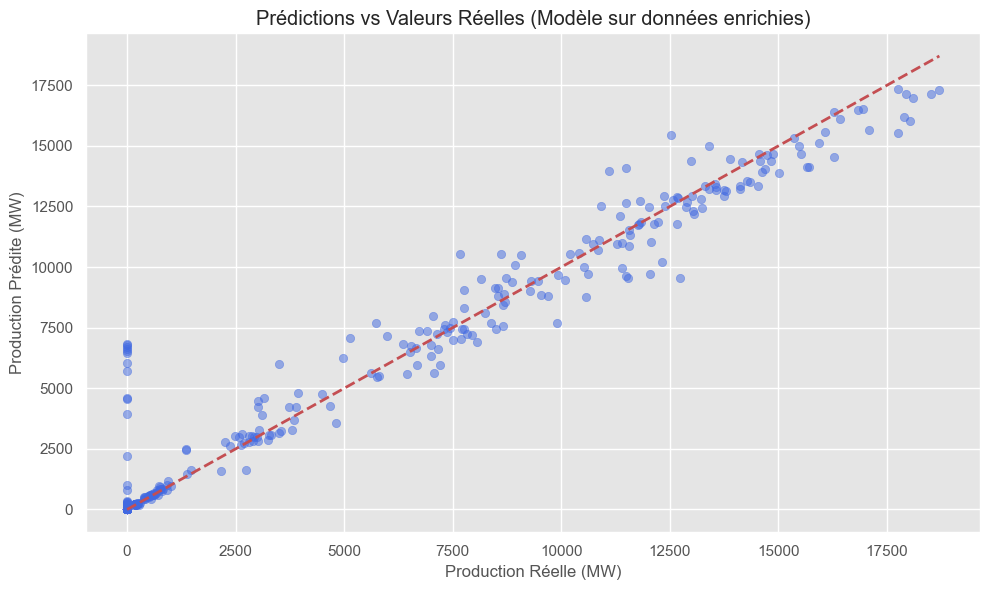

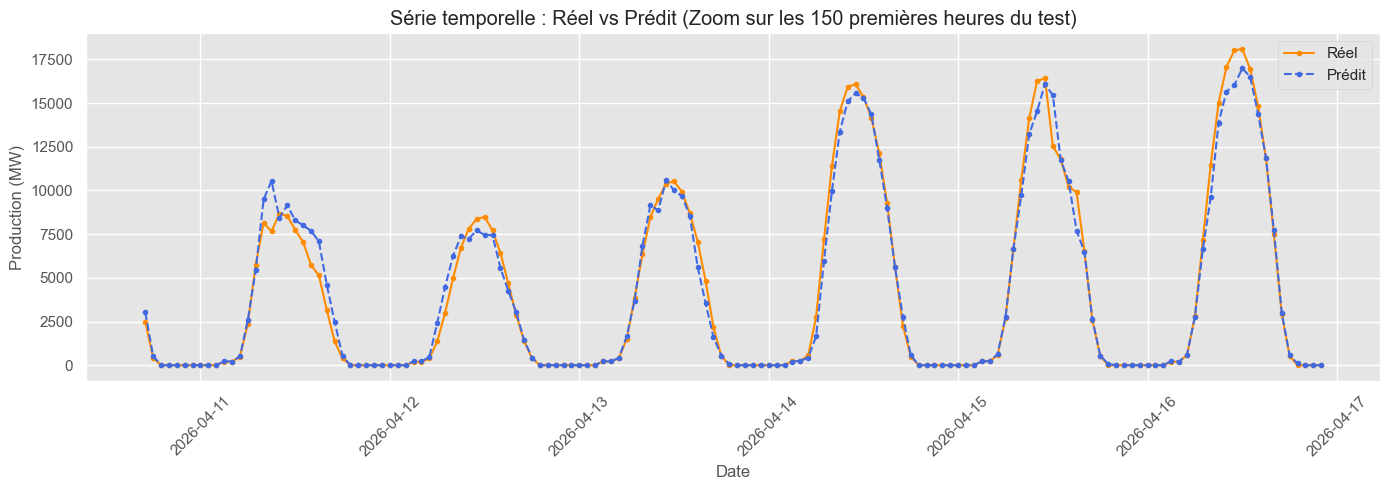

In [8]:

plt.figure(figsize=(10, 6))
plt.scatter(y_test_clean, y_pred_clean, alpha=0.5, color='royalblue')
plt.plot([y_test_clean.min(), y_test_clean.max()], [y_test_clean.min(), y_test_clean.max()], 'r--', lw=2)
plt.title("Prédictions vs Valeurs Réelles (Modèle sur données enrichies)")
plt.xlabel("Production Réelle (MW)")
plt.ylabel("Production Prédite (MW)")
plt.tight_layout()
plt.show()

# Graphique de la série temporelle (réel vs prédit sur un sous-échantillon test)
test_dates = df_fe['timestamp'].iloc[-len(y_test_clean):]

plt.figure(figsize=(14, 5))
plt.plot(test_dates[:150], y_test_clean[:150].values, label="Réel", color='darkorange', marker='.')
plt.plot(test_dates[:150], y_pred_clean[:150], label="Prédit", color='royalblue', linestyle='--', marker='.')
plt.title("Série temporelle : Réel vs Prédit (Zoom sur les 150 premières heures du test)")
plt.xlabel("Date")
plt.ylabel("Production (MW)")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
